# Lecture 08c — Satellite embeddings: from words to places

**AI-integrated Sustainable Finance (25881) · Lecture 8 lab, part 3 of 4**

In the NLP part of this subject you met **word embeddings**: every word becomes a vector, and
words used in similar contexts end up close together. You ran `most_similar()`, you saw
*king − man + woman ≈ queen*, and you used pre-trained vectors instead of training from scratch.

This notebook is the same idea, applied to **every 10 metre parcel of land on Earth**.

Google DeepMind's AlphaEarth Foundations turns a year of satellite observation into a
64-dimensional vector per pixel. Not a spectral index someone designed. A **learned coordinate
system**, built the same way word vectors are: by predicting context.

### The one sentence this notebook exists to make true

> **An embedding is a learned coordinate system in which similarity becomes geometry.**

Everything else — nearest neighbours, similarity search, analogy arithmetic, learning from a
handful of labels, change detection without an index — follows from that one property.

### Plan

1. **Rebuild a word embedding from scratch**, in about twenty lines, so the mechanism is not a
   black box.
2. **Map the concept across** from words to places, explicitly.
3. **Meet the real data**, including how it is stored and the trap that hides there.
4. **See the space**, search it, and do arithmetic in it.
5. **Learn from very few labels**, which is the commercial argument for the whole approach.
6. **Detect change without any index at all.**

**Prerequisites:** 08a and 08b. Needs `numpy`, `matplotlib` and `scikit-learn`. The satellite
section works offline if the network is unavailable.

In [1]:
# --- dependencies ----------------------------------------------------------
import importlib, sys

REQUIRED = {"numpy": "numpy", "matplotlib": "matplotlib", "sklearn": "scikit-learn"}
OPTIONAL = {"rasterio": "rasterio", "pyarrow": "pyarrow", "fsspec": "fsspec",
            "pandas": "pandas", "ipywidgets": "ipywidgets"}

def _missing(d):
    out = []
    for mod, pkg in d.items():
        try:
            importlib.import_module(mod)
        except Exception:
            out.append(pkg)
    return out

need, nice = _missing(REQUIRED), _missing(OPTIONAL)
if need and "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *need], check=False)
elif need:
    print("Missing:", " ".join(need))
    print("  conda install -c conda-forge " + " ".join(need))
else:
    print("Core packages present.")
if nice:
    print(f"Optional (live satellite path needs these): {' '.join(nice)}")

Core packages present.


In [2]:
import pathlib, urllib.request, re
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

HELPER = "esgsat.py"
REPO_RAW = ("https://raw.githubusercontent.com/VitaliAlexeev/"
            "AI_SustainableFinance_2026/main/helpers/esgsat.py")
if not pathlib.Path(HELPER).exists():
    try:
        urllib.request.urlretrieve(REPO_RAW, HELPER)
    except Exception as exc:
        print(f"Could not fetch esgsat.py ({type(exc).__name__}). Place it beside this notebook.")
import esgsat as E

USE_LIVE = True
AOI_LON, AOI_LAT = 151.21, -33.87      # Sydney
YEAR = 2024
WINDOW_PX = 256

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(25881)
print("Ready.")

Ready.


---
# Part 1 — Rebuilding a word embedding

### Why start with words?

Because you already have the intuition, and because the satellite version is genuinely the same
construction. If we start with 64 invisible dimensions over a landscape, "embedding" stays a
word you nod at. If we start with something you can read, it becomes a thing you understand.

### The problem embeddings solve

Suppose you represent words as **one-hot vectors**: a vocabulary of 40 words means 40 dimensions,
each word gets a 1 in its own slot and 0 everywhere else.

Run the next cell and look at what that representation says about meaning.

In [3]:
words = ["river", "stream", "forest", "concrete"]
V = len(words)
onehot = np.eye(V)

print("One-hot vectors:\n")
for w, v in zip(words, onehot):
    print(f"  {w:10s} {v}")

print("\nCosine similarity between every pair:\n")
print(f"{'':11s}" + "".join(f"{w:>11s}" for w in words))
for i, w in enumerate(words):
    print(f"  {w:9s}" + "".join(f"{float(onehot[i] @ onehot[j]):11.2f}" for j in range(V)))

print()
print("Every off-diagonal entry is zero. In this representation 'river' is exactly as")
print("similar to 'stream' as it is to 'concrete': not at all. The representation contains")
print("no information about meaning, because we never put any in.")

One-hot vectors:

  river      [1. 0. 0. 0.]
  stream     [0. 1. 0. 0.]
  forest     [0. 0. 1. 0.]
  concrete   [0. 0. 0. 1.]

Cosine similarity between every pair:

                 river     stream     forest   concrete
  river           1.00       0.00       0.00       0.00
  stream          0.00       1.00       0.00       0.00
  forest          0.00       0.00       1.00       0.00
  concrete        0.00       0.00       0.00       1.00

Every off-diagonal entry is zero. In this representation 'river' is exactly as
similar to 'stream' as it is to 'concrete': not at all. The representation contains
no information about meaning, because we never put any in.


### The idea: meaning comes from context

The distributional hypothesis, usually stated as *"you shall know a word by the company it
keeps"*. If two words appear in similar surroundings, treat them as similar.

That is all an embedding does. We will build one in three steps:

1. **Count co-occurrences.** For every pair of words, how often do they appear near each other?
2. **Reweight.** Raw counts are dominated by frequency, so convert to *positive pointwise mutual
   information*: how much more often do these two words co-occur than chance would predict?
3. **Compress.** The co-occurrence matrix is large and sparse. A truncated singular value
   decomposition squeezes it into a few dense dimensions.

Steps 1 to 3 are essentially how GloVe works. Modern models such as word2vec and BERT differ in
the training objective, not in the underlying idea.

Our corpus is 64 hand-written sentences about landscapes, land use and carbon. That is
**absurdly small** — real embeddings train on billions of words. Take away the mechanism, not
the quality.

In [4]:
CORPUS = '''the river flows past the village and the water is muddy after the rain
boats travel along the river carrying rice to the market town
the lake holds water through the dry season and fish live in the lake
water from the river feeds the canal that irrigates the rice field
the stream runs down from the hills into the river below the forest
fishermen set nets in the river where the water is deep and slow
the canal carries water from the lake to the field beyond the village
after heavy rain the river rises and the water floods the low field
the mangrove forest grows where the river meets the salty sea water
salt water from the sea moves up the river during the high tide
the forest canopy is dense and green and the trees hold much carbon
mangrove trees grow in mud along the coast and shelter young fish
loggers cut trees and the forest canopy opens and the soil dries
the tall trees of the forest shade the ground and keep the soil moist
a dense forest stores more carbon than a young forest of small trees
the canopy of the mangrove forest protects the coast from the storm
green leaves in the canopy absorb light and the trees grow tall
fire burned the forest and the blackened trees no longer hold carbon
the farmer plants rice in the field before the rain arrives
the field of rice turns green and then golden before the harvest
farmers harvest the crop and the bare field is left dry and brown
a tractor works the bare soil of the field after the harvest
the crop grows well when water reaches the field through the canal
wheat and rice are the main crop of the farm near the town
the farmer waits for rain because the dry soil cannot feed the crop
bare soil in the empty field is brown and dusty in the dry season
the town has many buildings and roads and the streets are crowded
people live in the city where buildings of concrete line every road
the road from the town crosses the river on a long concrete bridge
a city grows outward and buildings replace the field and the forest
traffic moves along the road between the town and the distant city
the village is small but the city has tall buildings and wide roads
concrete and asphalt cover the ground where the city has grown
new buildings rise at the edge of the city near the old farm
the market in the town sells rice and fish from the river
rain falls on the forest and the field and the river and the town
in the dry season the soil is hard and the crop needs water
the storm brought rain and the river flooded the field and the road
satellites watch the forest and the field and the growing city
a map shows the river the forest the field and the town together

the mangrove roots trap mud and slow the flow of water at the coast
young mangrove trees colonise new mud banks along the tidal river
dense canopy shades the forest floor and keeps the soil damp
a burned forest shows blackened soil where the canopy has gone
fire leaves bare soil and the dry season makes the ground dusty
the harvest leaves stubble on the field and the soil turns brown
irrigation brings water along the canal to the dry rice field
the reservoir stores water for the city through the dry season
the dam holds back the river and the reservoir fills with water
turbid water in the estuary carries mud from the swollen river
the tide pushes salt water up the estuary past the mangrove coast
green crop covers the field until the farmer begins the harvest
wheat ripens in the dry field and the farmer waits for the harvest
new roads spread from the city and concrete covers the old field
the suburb grows and buildings replace the crop and the trees
asphalt roads and concrete buildings warm the city in summer
the port on the coast handles rice and wheat from the farm
a bridge of concrete carries the road across the wide river
the village near the mangrove depends on fish from the estuary
carbon is stored in the trees the roots and the forest soil
logging removes trees and releases carbon from the forest
a young plantation stores less carbon than the old dense forest
drought dries the soil and the crop fails in the bare field
flood water covers the field and the road near the swollen river'''

# Function words carry grammar, not topic, so we drop them. Real pipelines do the same.
STOP = set('''a after along an and are as at back be been before begins below beyond brings but by carries colonise covers cut depends down dries during each every fails falls fills flow flows for from grow growing grows handles has have he holds i if in into is it its keeps large leaves less live lives long main makes many more most moves much near new no not of old on or out past pushes releases removes replace ripens rises runs sells set shades she shows slow small so spread stores than that the then these they this those through to trap travel turns until up waits warm was we were when where which who wide with works you'''.split())

def tokenise(text):
    return [w for w in re.findall(r"[a-z]+", text.lower()) if w not in STOP]

sentences = [tokenise(s) for s in CORPUS.strip().split("\n") if s.strip()]
counts = Counter(w for s in sentences for w in s)
print(f"{len(sentences)} sentences, {sum(counts.values())} content tokens, "
      f"{len(counts)} distinct words")
print("\nMost frequent:", ", ".join(f"{w}({c})" for w, c in counts.most_common(10)))

64 sentences, 369 content tokens, 130 distinct words

Most frequent: field(21), river(18), forest(18), water(17), soil(12), trees(11), city(10), dry(9), rice(8), town(8)


In [5]:
# Step 1: co-occurrence counts, weighted by how close two words are.
WINDOW, DIM, MIN_COUNT = 4, 32, 3

vocab = sorted(w for w, c in counts.items() if c >= MIN_COUNT)
widx = {w: i for i, w in enumerate(vocab)}
n = len(vocab)

Co = np.zeros((n, n))
for s in sentences:
    ids = [widx[w] for w in s if w in widx]
    for i, a in enumerate(ids):
        for j in range(max(0, i - WINDOW), min(len(ids), i + WINDOW + 1)):
            if i != j:
                Co[a, ids[j]] += 1.0 / abs(i - j)     # closer words count for more

print(f"co-occurrence matrix: {Co.shape}, {np.count_nonzero(Co)} non-zero entries "
      f"({np.count_nonzero(Co)/Co.size*100:.0f}% dense)")

# Step 2: positive pointwise mutual information.
total = Co.sum()
p_w = Co.sum(axis=1, keepdims=True) / total
p_c = Co.sum(axis=0, keepdims=True) / total
with np.errstate(divide="ignore", invalid="ignore"):
    ppmi = np.nan_to_num(np.maximum(np.log((Co / total) / (p_w @ p_c)), 0.0))

# Step 3: truncated SVD, then scale every vector to unit length.
U, S, _ = np.linalg.svd(ppmi, full_matrices=False)
W = U[:, :DIM] * S[:DIM]
W /= np.linalg.norm(W, axis=1, keepdims=True)

print(f"word embedding: {W.shape[0]} words x {W.shape[1]} dimensions")
print(f"all unit length: {np.allclose(np.linalg.norm(W, axis=1), 1.0)}")

co-occurrence matrix: (38, 38), 439 non-zero entries (30% dense)
word embedding: 38 words x 32 dimensions
all unit length: True


### Does it work?

The test is the one you ran in the NLP lectures: **nearest neighbours**. Because every vector has
unit length, cosine similarity is just a dot product, so the whole thing is one matrix
multiplication.

Predict before you run it. Which words should sit near `soil`? Near `city`?

In [6]:
def most_similar(word, k=5):
    if word not in widx:
        return f"{word}: not in vocabulary"
    sims = W @ W[widx[word]]
    order = np.argsort(-sims)[1:k+1]          # skip the word itself
    return ", ".join(f"{vocab[i]} ({sims[i]:.2f})" for i in order)

for w in ["river", "forest", "city", "crop", "soil", "carbon", "mangrove", "concrete"]:
    print(f"  {w:10s} -> {most_similar(w, 4)}")

print()
print("Nobody told the model that a city has roads, or that soil is dry and bare.")
print("It only ever saw which words appear near which other words.")

  river      -> estuary (0.45), lake (0.41), road (0.41), field (0.40)
  forest     -> green (0.63), young (0.60), carbon (0.59), dense (0.58)
  city       -> roads (0.68), buildings (0.68), concrete (0.62), tall (0.57)
  crop       -> harvest (0.60), brown (0.57), field (0.54), wheat (0.51)
  soil       -> dry (0.56), bare (0.55), brown (0.53), field (0.48)
  carbon     -> canopy (0.67), forest (0.59), dense (0.46), young (0.40)
  mangrove   -> mud (0.67), estuary (0.60), coast (0.58), fish (0.57)
  concrete   -> tall (0.63), city (0.62), town (0.61), buildings (0.54)

Nobody told the model that a city has roads, or that soil is dry and bare.
It only ever saw which words appear near which other words.


In [7]:
# Analogy arithmetic: the operation that made word embeddings famous.
def analogy(a, b, c, k=3):
    v = W[widx[a]] - W[widx[b]] + W[widx[c]]
    v /= np.linalg.norm(v)
    sims = W @ v
    return [vocab[i] for i in np.argsort(-sims) if vocab[i] not in (a, b, c)][:k]

for a, b, c in [("forest", "trees", "city"), ("river", "water", "city"),
                ("crop", "field", "forest")]:
    print(f"  {a} - {b} + {c}  =  {analogy(a, b, c)}")

print()
print("Read these sceptically. Analogy arithmetic works less reliably than folklore")
print("suggests, even on full-sized embeddings, and the standard evaluation excludes")
print("the three input words - which we also do above, and which does a lot of the work.")

  forest - trees + city  =  ['tall', 'concrete', 'town']
  river - water + city  =  ['buildings', 'roads', 'concrete']
  crop - field + forest  =  ['canopy', 'dense', 'carbon']

Read these sceptically. Analogy arithmetic works less reliably than folklore
suggests, even on full-sized embeddings, and the standard evaluation excludes
the three input words - which we also do above, and which does a lot of the work.


## The mapping, made explicit

This is the hinge of the notebook. Everything you just did transfers, term for term.

| | **Word embedding** | **Satellite embedding (AlphaEarth)** |
|---|---|---|
| **What is a token?** | One word | One 10 m × 10 m parcel of land, for one year |
| **Vocabulary size** | ~10⁵ words | ~10¹² parcels — every 10 m of land and coastal water on Earth |
| **What is "context"?** | The words either side of it | Other sensors, other dates, neighbouring pixels |
| **Where does supervision come from?** | Nowhere. Context only | Nowhere. Context only |
| **Dimensions** | 100–300 (GloVe) | **64** |
| **What is close together?** | Words used similarly | **Places that look and behave similarly** |
| **Is one dimension meaningful?** | Not by design | Not by design — but see Part 8 |
| **Vector length** | Usually normalised | Normalised to exactly 1 |
| **How is it used?** | Trained once, reused for many tasks | Trained once, reused for many tasks |
| **Main practical benefit** | Far fewer labels needed downstream | Far fewer labels needed downstream |

### Three places the analogy breaks

**Words are discrete, places are continuous.** There is a finite list of English words. There is
no finite list of places, and no two parcels are identical, so there is no lookup table — the
embedding is a *field*, defined everywhere.

**One vector per word, but one vector per place per year.** A classic word embedding gives
`bank` a single vector regardless of context. AlphaEarth gives each parcel a *new* vector every
year, which makes it closer in spirit to a contextual model such as BERT than to a static
lookup.

**You cannot read a place.** When a word embedding misbehaves you can look at the neighbours and
judge them, because you speak the language. With places you need ground truth, and ground truth
is exactly what was scarce enough to motivate the whole approach.

---
# Part 2 — Meet the satellite embeddings

**AlphaEarth Foundations** was published by Google DeepMind and Google in July 2025
(arXiv:2507.22291). The derived product, the **Satellite Embedding** dataset, is free and public.

Verified anonymously on 1 September 2026, with no Google account:

| Property | Value |
|---|---|
| Coverage | All land and coastal water, globally |
| Resolution | 10 m |
| Dimensions | 64 per pixel per year |
| Years | 2017 to 2025 |
| Inputs | Optical, radar, LiDAR-derived canopy height, elevation, climate reanalysis, text |
| Storage | Cloud-optimised GeoTIFF on public Google Cloud Storage, **not requester-pays** |
| Tile | 8192 × 8192 × 64 bands, int8, 300 MB to 3.2 GB each |
| Licence | CC-BY 4.0 |

The licence requires attribution. Put this on anything you publish:

> *The AlphaEarth Foundations Satellite Embedding dataset is produced by Google and
> Google DeepMind.*

### The trap in how they are stored

You met the reflectance trap in 08a: Sentinel-2 stores integers, and reflectance comes back
through a **linear** map, so ratio indices survive the scale factor.

Embeddings are stored as **int8**, and the published de-quantisation is **not** linear:

$$x = \operatorname{sign}(q)\left(\frac{|q|}{127.5}\right)^{2}, \qquad q \in [-127, 127]$$

with $q = -128$ reserved for no data. Squaring is monotone, so a map of raw values still looks
sensible — but **no ratio, no difference, no distance and no dot product survives**. Since every
technique in this notebook is a dot product, skipping this step breaks all of it.

There is a free correctness test. Google normalises each de-quantised 64-vector to Euclidean
length **exactly 1**. If your norms are not near 1, something is wrong upstream. Very few
datasets hand you an invariant like that.

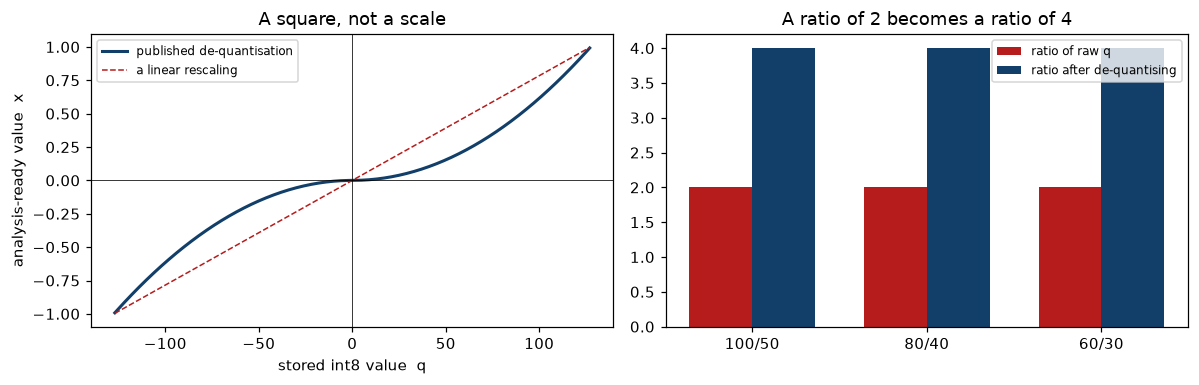

q = -127 -> -0.992172     q = 0 -> +0.000000     q = +127 -> +0.992172
q = -128 -> nan   (no data)
round trip is lossless: True


In [8]:
q = np.arange(-127, 128, dtype="int8")
x = E.aef_dequantise(q)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(q, x, lw=2, color="#123F69", label="published de-quantisation")
a1.plot(q, q / 127.5, lw=1, ls="--", color="#B71C1C", label="a linear rescaling")
a1.set_xlabel("stored int8 value  q"); a1.set_ylabel("analysis-ready value  x")
a1.set_title("A square, not a scale"); a1.legend(fontsize=8)
a1.axhline(0, lw=0.5, color="k"); a1.axvline(0, lw=0.5, color="k")

f = lambda v: E.aef_dequantise(np.asarray(v, dtype="float32"))
raw = np.array([100/50, 80/40, 60/30])
deq = f([100, 80, 60]) / f([50, 40, 30])
a2.bar(np.arange(3) - 0.18, raw, 0.36, label="ratio of raw q", color="#B71C1C")
a2.bar(np.arange(3) + 0.18, deq, 0.36, label="ratio after de-quantising", color="#123F69")
a2.set_xticks(range(3)); a2.set_xticklabels(["100/50", "80/40", "60/30"])
a2.set_title("A ratio of 2 becomes a ratio of 4"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"q = -127 -> {float(x[0]):+.6f}     q = 0 -> {float(x[127]):+.6f}     "
      f"q = +127 -> {float(x[-1]):+.6f}")
print(f"q = -128 -> {E.aef_dequantise(np.array([-128], dtype='int8'))[0]}   (no data)")
print(f"round trip is lossless: "
      f"{int(np.max(np.abs(E.aef_quantise(x).astype(int) - q.astype(int)))) == 0}")

### Loading a window

A tile can be 3.2 GB, so nobody downloads one. The workflow is: look up which tile covers your
coordinate in the published index, then read **only the blocks that intersect your window** over
HTTP. A 256 × 256 window takes about a second.

If the network is unavailable, the fallback generates synthetic embeddings with the same dtype,
the same no-data sentinel, and the same non-linear quantisation, so every cell below still runs.

In [9]:
EMB, SOURCE = None, "synthetic"

if USE_LIVE:
    try:
        idx_df = E.aef_load_index(year=YEAR)
        hits = E.aef_find_tiles(idx_df, AOI_LON, AOI_LAT, year=YEAR)
        print(f"index: {len(idx_df):,} tiles for {YEAR}; {len(hits)} cover our point")
        if len(hits):
            url = E.aef_tile_url(hits.iloc[0]["path"])
            print(f"reading {url.rsplit('/', 1)[-1]}")
            EMB, TR, CRS = E.aef_read_window(url, AOI_LON, AOI_LAT,
                                             size_px=WINDOW_PX, dequantise=False)
            SOURCE = "live"
    except Exception as exc:
        print(f"Live path unavailable: {type(exc).__name__}: {exc}")

if EMB is None:
    scene = E.demo_scene(size=WINDOW_PX, as_dn=True, cloud=True,
                         noise_sd=0.05, smooth_px=6)
    LABELS = scene["SCL"]
    EMB = E.demo_embedding(LABELS, noise=0.06, smooth_px=6)
else:
    LABELS = None

print(f"\nsource : {SOURCE}")
print(f"cube   : {EMB.shape}  dtype {EMB.dtype}  (bands, rows, cols)")
print(f"no-data: {float(np.mean(EMB[0] == E.AEF_NODATA))*100:.1f}% of pixels")

index: 34,149 tiles for 2024; 1 cover our point
reading xzner84rkkjdvpdtx-0000000000-0000008192.tiff

source : live
cube   : (64, 256, 256)  dtype int8  (bands, rows, cols)
no-data: 0.0% of pixels


In [10]:
# De-quantise, then run the free correctness test.
X = E.aef_dequantise(EMB)
med, frac = E.aef_check_unit_norm(X)
print(f"median vector norm after de-quantising : {med:.4f}")
print(f"within 2% of 1.0                       : {frac*100:.1f}% of pixels")

raw_norm, _ = E.aef_check_unit_norm(
    np.where(EMB == E.AEF_NODATA, np.nan, EMB).astype("float32"))
print(f"median norm if you SKIP de-quantising  : {raw_norm:,.1f}   <- nowhere near 1")

assert abs(med - 1.0) < 0.05, "Unit-norm test failed: the read or the maths is wrong."
print("\nPASS. Every pixel is a unit vector in 64 dimensions, so from here on")
print("cosine similarity is simply a dot product.")

# Flatten once: (pixels, 64). Everything below uses this.
B, H, Wd = X.shape
flat = X.reshape(B, -1).T
finite = np.all(np.isfinite(flat), axis=1)
print(f"\nflat matrix: {flat.shape[0]:,} pixels x {flat.shape[1]} dimensions, "
      f"{finite.sum():,} usable")

median vector norm after de-quantising : 1.0001
within 2% of 1.0                       : 100.0% of pixels
median norm if you SKIP de-quantising  : 323.7   <- nowhere near 1

PASS. Every pixel is a unit vector in 64 dimensions, so from here on
cosine similarity is simply a dot product.

flat matrix: 65,536 pixels x 64 dimensions, 65,536 usable


---
# Part 3 — Seeing a 64-dimensional space

You cannot look at 64 dimensions. But you can **project** them down to three and map those to
red, green and blue.

The result is an image in which **colour is semantic similarity**. Two parcels that render in
the same colour are ones the model considers alike, whatever that turns out to mean physically.
Nobody chose the categories, and nobody labelled anything.

Compare this with 08a, where we chose which three bands to display. Here the three components
are chosen *by the data*, as the directions of greatest variation.

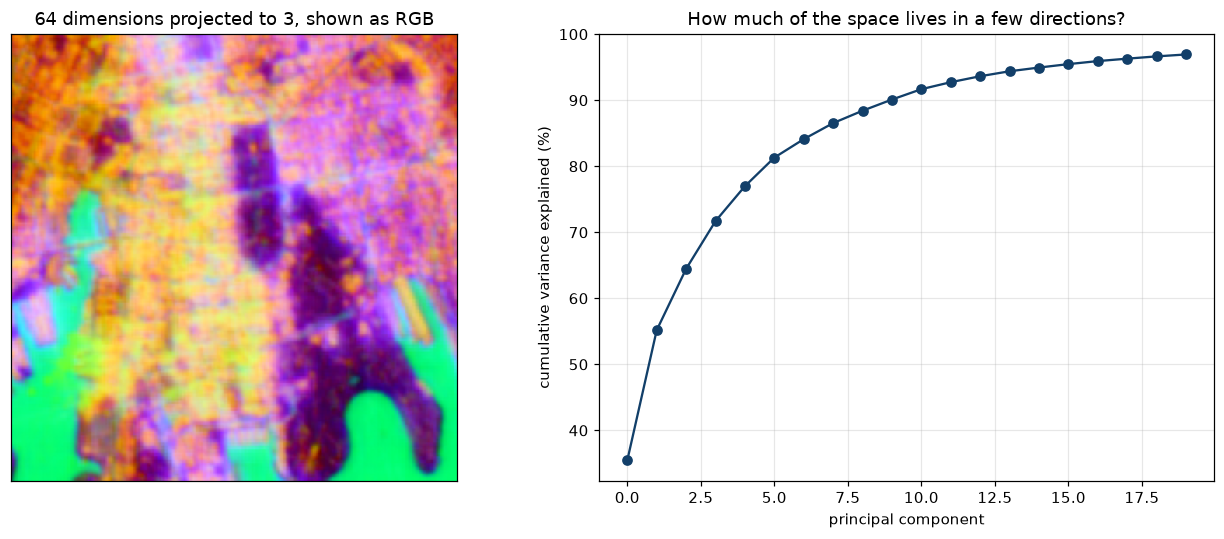

first 3 components explain 64.5% of the variance
first 10 components explain 90.1%

The AlphaEarth Foundations Satellite Embedding dataset is produced by Google and Google DeepMind.


In [11]:
def pca_rgb(flat, mask, shape, n=3):
    # Project to the top n principal components and scale each to 0-1 for display.
    # Intersect with our own finite check: a mask computed for one year does not
    # necessarily hold for another, because the no-data pattern differs.
    mask = np.asarray(mask) & np.all(np.isfinite(flat), axis=1)
    Xg = flat[mask]
    Xc = Xg - Xg.mean(axis=0, keepdims=True)
    _u, _s, vt = np.linalg.svd(Xc, full_matrices=False)
    comps = (flat - Xg.mean(axis=0, keepdims=True)) @ vt[:n].T
    out = np.full((flat.shape[0], n), np.nan, dtype="float32")
    out[mask] = comps[mask]
    for i in range(n):
        lo, hi = np.nanpercentile(out[:, i], [2, 98])
        out[:, i] = np.clip((out[:, i] - lo) / max(float(hi - lo), 1e-9), 0, 1)
    var = (_s ** 2) / (_s ** 2).sum()
    return np.nan_to_num(out.reshape(shape + (n,))), comps, var

rgb, comps, var = pca_rgb(flat, finite, (H, Wd))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
a1.imshow(rgb); a1.set_title("64 dimensions projected to 3, shown as RGB")
a1.set_xticks([]); a1.set_yticks([])
a2.plot(np.cumsum(var[:20]) * 100, marker="o", color="#123F69")
a2.set_xlabel("principal component"); a2.set_ylabel("cumulative variance explained (%)")
a2.set_title("How much of the space lives in a few directions?")
a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"first 3 components explain {var[:3].sum()*100:.1f}% of the variance")
print(f"first 10 components explain {var[:10].sum()*100:.1f}%")
print(f"\n{E.AEF_ATTRIBUTION}")

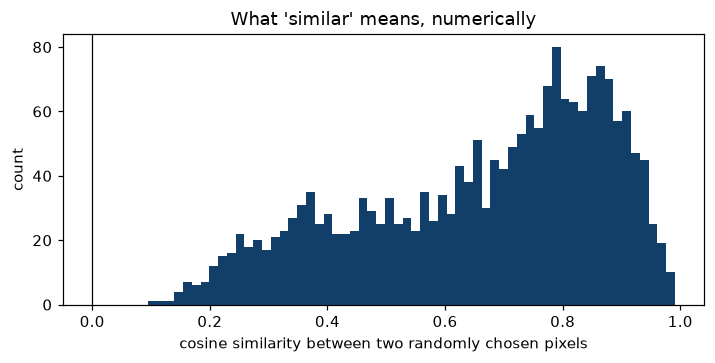

random pairs: median +0.714, 5th +0.266, 95th +0.930

This is your baseline. A similarity of 0.9 only means something once you know
what two unrelated places score. Read the next section against this distribution.


In [12]:
# What does 'similar' look like as a number? Sample random pairs.
samp = rng.choice(np.flatnonzero(finite), size=min(4000, finite.sum()), replace=False)
Xs = flat[samp]
pair_sim = (Xs[:2000] * Xs[2000:4000]).sum(axis=1) if len(samp) >= 4000 else \
           (Xs[:len(Xs)//2] * Xs[len(Xs)//2:2*(len(Xs)//2)]).sum(axis=1)

fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.hist(pair_sim, bins=60, color="#123F69")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("cosine similarity between two randomly chosen pixels")
ax.set_ylabel("count"); ax.set_title("What 'similar' means, numerically")
plt.tight_layout(); plt.show()

print(f"random pairs: median {np.median(pair_sim):+.3f}, "
      f"5th {np.percentile(pair_sim, 5):+.3f}, 95th {np.percentile(pair_sim, 95):+.3f}")
print()
print("This is your baseline. A similarity of 0.9 only means something once you know")
print("what two unrelated places score. Read the next section against this distribution.")

---
# Part 4 — Similarity search: `most_similar()` for places

This is the direct analogue of what you did with words, and it is the single most useful thing
the representation gives you.

**Pick a pixel. Ask: where else on this map looks like it?**

Because every vector has unit length, the answer is one matrix multiplication — the similarity
of a query pixel to all 65,536 others at once. No training, no labels, no threshold chosen in
advance.

Think about what that means operationally. *"Find me every hectare in this province that looks
like this illegal mine"* becomes a dot product.

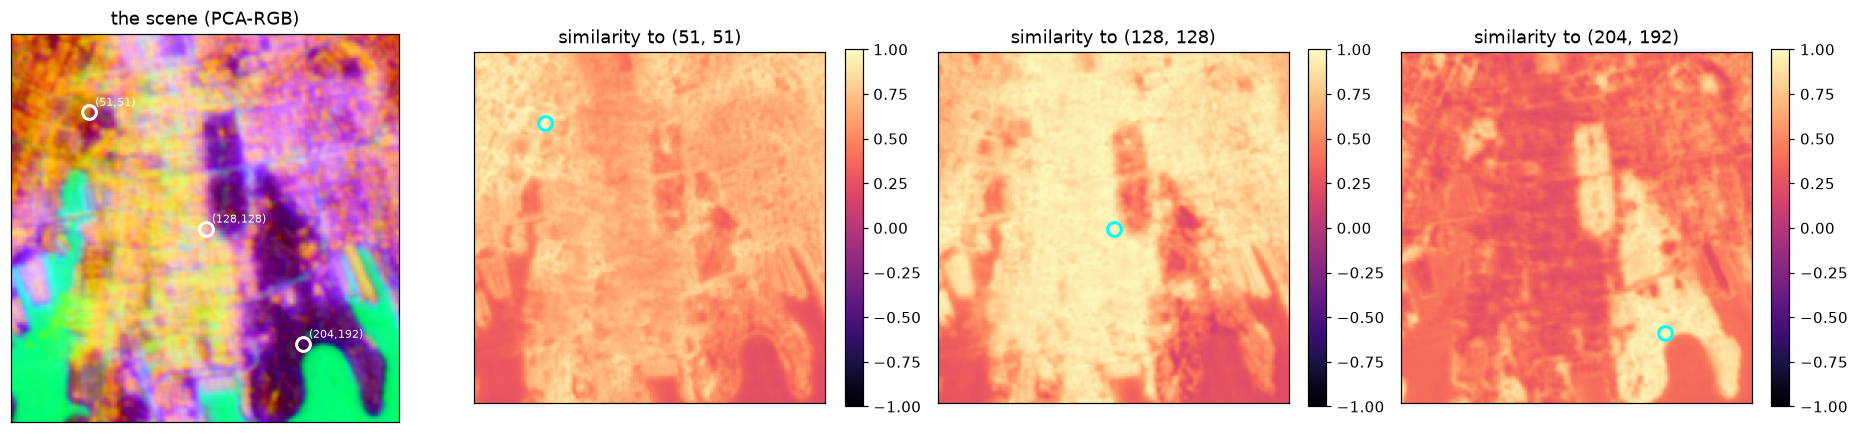

Three queries, three different regions light up. Nothing was trained.


In [13]:
def similarity_to(row, col):
    # Cosine similarity of one pixel to every pixel, as a 2-D map.
    query = X[:, row, col]
    if not np.all(np.isfinite(query)):
        raise ValueError("That pixel is no-data. Pick another.")
    return (flat @ query).reshape(H, Wd)

# Three query points, chosen to sit in visibly different parts of the scene.
QUERIES = [(H // 5, Wd // 5), (H // 2, Wd // 2), (4 * H // 5, 3 * Wd // 4)]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
axes[0].imshow(rgb); axes[0].set_title("the scene (PCA-RGB)")
for (r, c) in QUERIES:
    axes[0].plot(c, r, "o", ms=9, mfc="none", mec="white", mew=2)
    axes[0].annotate(f"({r},{c})", (c, r), color="white", fontsize=7,
                     xytext=(4, 4), textcoords="offset points")
for ax, (r, c) in zip(axes[1:], QUERIES):
    sim = similarity_to(r, c)
    im = ax.imshow(sim, cmap="magma", vmin=-1, vmax=1)
    ax.plot(c, r, "o", ms=9, mfc="none", mec="cyan", mew=2)
    ax.set_title(f"similarity to ({r}, {c})")
    fig.colorbar(im, ax=ax, fraction=0.046)
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print("Three queries, three different regions light up. Nothing was trained.")

### Choose your own query, and a threshold

Change `QUERY_ROW`, `QUERY_COL` and `THRESHOLD` below and re-run. If `ipywidgets` is installed
you get sliders instead; if not, the plain variables work exactly the same way.

**The threshold is the interesting part.** A similarity map is continuous. Turning it into a
*decision* — this parcel counts, that one does not — requires a cut-off, and nothing in the data
tells you where to put it. That is the same modelling decision you met with index thresholds in
08a, wearing different clothes.

In [14]:
QUERY_ROW, QUERY_COL = H // 2, Wd // 2
THRESHOLD = 0.80

def show_query(row, col, thr):
    sim = similarity_to(row, col)
    hit = sim >= thr
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
    axes[0].imshow(rgb); axes[0].set_title("scene")
    axes[1].imshow(sim, cmap="magma", vmin=-1, vmax=1); axes[1].set_title("similarity")
    axes[2].imshow(hit, cmap="Greys_r"); axes[2].set_title(f"similarity >= {thr:.2f}")
    for a in axes:
        a.plot(col, row, "o", ms=9, mfc="none", mec="cyan", mew=2)
        a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()
    area = float(np.nansum(hit)) * 0.01      # 10 m pixels -> hectares
    print(f"pixels above threshold : {int(np.nansum(hit)):,} "
          f"({float(np.nanmean(hit))*100:.1f}% of the scene)")
    print(f"equivalent area        : {area:,.1f} hectares")

try:
    import ipywidgets as widgets
    from IPython.display import display
    widgets.interact(
        show_query,
        row=widgets.IntSlider(min=0, max=H-1, step=1, value=QUERY_ROW, description="row"),
        col=widgets.IntSlider(min=0, max=Wd-1, step=1, value=QUERY_COL, description="col"),
        thr=widgets.FloatSlider(min=-1.0, max=1.0, step=0.02, value=THRESHOLD,
                                description="threshold"),
    )
except Exception:
    print("ipywidgets unavailable; using the plain variables above.\n")
    show_query(QUERY_ROW, QUERY_COL, THRESHOLD)

interactive(children=(IntSlider(value=128, description='row', max=255), IntSlider(value=128, description='col'…

---
# Part 5 — Does analogy arithmetic work on places?

In Part 1 we computed `forest − trees + city`. The same operation is available here: average the
vectors of some *forest* pixels, subtract, add, and see what the result is nearest to.

**I do not know whether this works, and neither does the literature, particularly.** Analogy
arithmetic on words is weaker than its reputation, and there is no reason to assume it transfers.
We are running it because finding out is more useful than assuming.

Predict first: do you expect *(urban) − (vegetation) + (water)* to land somewhere sensible?

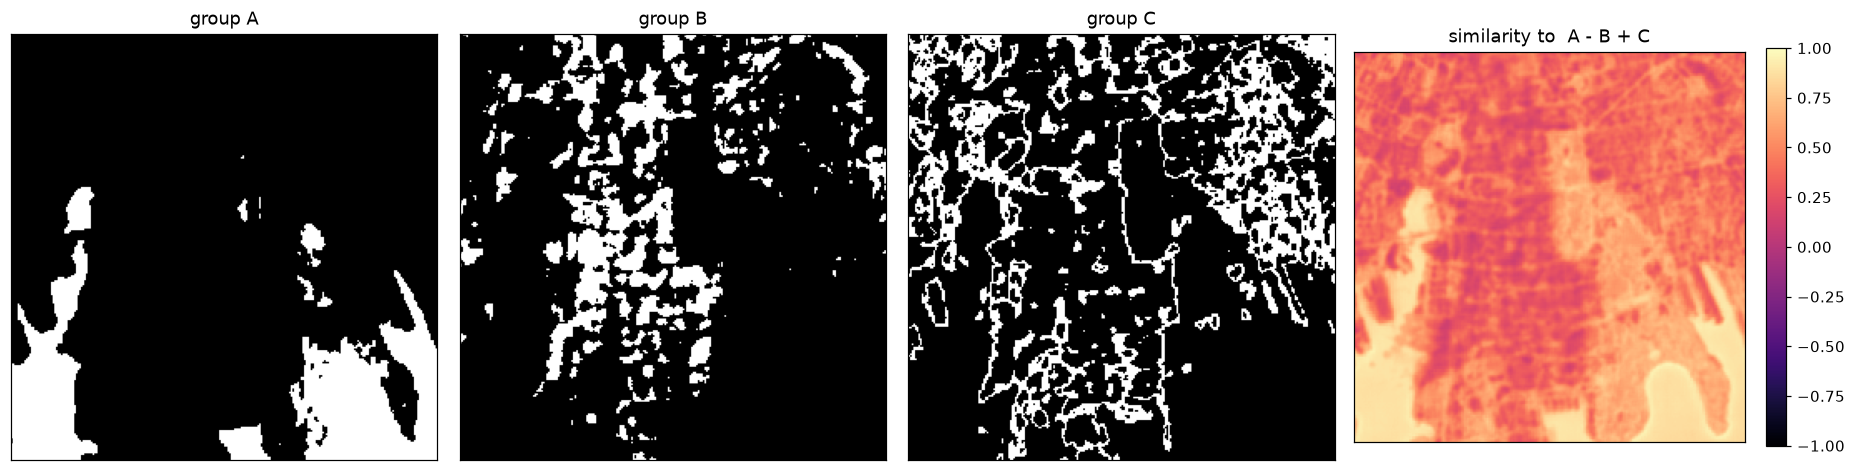

  cosine(A - B + C, prototype A) = +0.966
  cosine(A - B + C, prototype B) = +0.266
  cosine(A - B + C, prototype C) = +0.483

Interpretation. If the result is simply nearest to C, the subtraction did nothing
and the arithmetic is not carrying meaning - it is just returning what you added.
That is the usual outcome, and it is worth knowing before you build on it.


In [15]:
# Build class prototypes: the mean vector of a group of pixels, renormalised.
def prototype(mask):
    v = np.nanmean(flat[mask.ravel() & finite], axis=0)
    return v / np.linalg.norm(v)

# Define groups from the PCA image, so this works whatever the data source.
c0 = comps[:, 0]
lo, hi = np.nanpercentile(c0[finite], [15, 85])
grp_a = (c0 <= lo).reshape(H, Wd)      # one end of the dominant axis
grp_b = (c0 >= hi).reshape(H, Wd)      # the other end
grp_c = (np.abs(c0 - np.nanmedian(c0[finite])) <
         0.2 * np.nanstd(c0[finite])).reshape(H, Wd)

A, Bp, Cp = prototype(grp_a), prototype(grp_b), prototype(grp_c)
result = A - Bp + Cp
result /= np.linalg.norm(result)

sim_result = (flat @ result).reshape(H, Wd)
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, m, t in zip(axes[:3], [grp_a, grp_b, grp_c], ["group A", "group B", "group C"]):
    ax.imshow(m, cmap="Greys_r"); ax.set_title(t)
im = axes[3].imshow(sim_result, cmap="magma", vmin=-1, vmax=1)
axes[3].set_title("similarity to  A - B + C")
fig.colorbar(im, ax=axes[3], fraction=0.046)
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

for name, proto in [("A", A), ("B", Bp), ("C", Cp)]:
    print(f"  cosine(A - B + C, prototype {name}) = {float(result @ proto):+.3f}")
print()
print("Interpretation. If the result is simply nearest to C, the subtraction did nothing")
print("and the arithmetic is not carrying meaning - it is just returning what you added.")
print("That is the usual outcome, and it is worth knowing before you build on it.")

---
# Part 6 — Learning from very few labels

This is the commercial argument, and the reason a fund would care.

The scarce resource in environmental analytics is **labels**: field plots, soil cores, verified
land cover. They cost money and time. A representation that lets you fit a usable model from
thirty labels instead of thirty thousand changes what is affordable.

The AlphaEarth paper's central claim is about exactly this: the embeddings outperformed every
featurisation tested **without retraining**, and the advantage was largest where labels were
scarce.

We test the shape of that claim here: accuracy against the number of labels per class.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

# Labels. Live: derived from the PCA structure, so this is a self-consistency test.
# Offline: the synthetic land-cover map.
if LABELS is not None:
    y2d = np.full((H, Wd), -1, int)
    for code, lab in {6: 0, 4: 1, 5: 2}.items():
        y2d[LABELS[:H, :Wd] == code] = lab
    LABEL_NAME = {0: "water", 1: "vegetation", 2: "not vegetated"}
else:
    y2d = np.full((H, Wd), -1, int)
    y2d[grp_a] = 0; y2d[grp_b] = 1; y2d[grp_c] = 2
    LABEL_NAME = {0: "cluster A", 1: "cluster B", 2: "cluster C"}

y = y2d.ravel()
ok = finite & (y >= 0)
rows_i, cols_i = np.divmod(np.flatnonzero(ok), Wd)
Xf, yf = flat[ok], y[ok]
groups = (rows_i // 32) * 1000 + (cols_i // 32)      # spatial blocks, as in 08b and 08d

for k, v in LABEL_NAME.items():
    print(f"  {v:16s} {int(np.sum(yf == k)):7,d} pixels")
print(f"\n{len(np.unique(groups))} spatial blocks for grouped cross-validation")

  cluster A          9,831 pixels
  cluster B          9,831 pixels
  cluster C         15,230 pixels

64 spatial blocks for grouped cross-validation


     5 labels per class -> accuracy 0.773 (sd 0.124)
    10 labels per class -> accuracy 0.840 (sd 0.083)
    25 labels per class -> accuracy 0.923 (sd 0.030)
    50 labels per class -> accuracy 0.957 (sd 0.014)
   100 labels per class -> accuracy 0.979 (sd 0.006)
   250 labels per class -> accuracy 0.984 (sd 0.004)


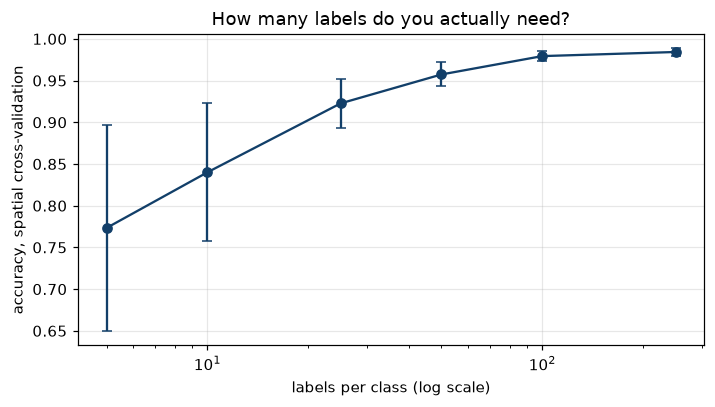


Going from 5 to 250 labels per class buys +0.211 accuracy.
If the curve is already flat at the left-hand end, the extra labelling
budget is being spent on nothing. That is the finding worth reporting.


In [17]:
def few_shot(n_per_class, repeats=5):
    accs = []
    for r in range(repeats):
        rs = np.random.default_rng(100 + r)
        pick = []
        for k in LABEL_NAME:
            avail = np.flatnonzero(yf == k)
            if avail.size == 0:
                continue
            pick.append(rs.choice(avail, size=min(n_per_class, avail.size), replace=False))
        pick = np.concatenate(pick)
        clf = RandomForestClassifier(n_estimators=60, min_samples_leaf=1,
                                     n_jobs=-1, random_state=r)
        cv = GroupKFold(n_splits=min(3, len(np.unique(groups[pick]))))
        try:
            s = cross_val_score(clf, Xf[pick], yf[pick], cv=cv,
                                groups=groups[pick], n_jobs=1)
            accs.append(s.mean())
        except Exception:
            pass
    return (np.mean(accs), np.std(accs)) if accs else (np.nan, np.nan)

NS = [5, 10, 25, 50, 100, 250]
means, sds = [], []
for n_ in NS:
    m, s = few_shot(n_)
    means.append(m); sds.append(s)
    print(f"  {n_:4d} labels per class -> accuracy {m:.3f} (sd {s:.3f})")

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.errorbar(NS, means, yerr=sds, marker="o", capsize=3, color="#123F69")
ax.set_xscale("log"); ax.set_xlabel("labels per class (log scale)")
ax.set_ylabel("accuracy, spatial cross-validation")
ax.set_title("How many labels do you actually need?")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

if np.isfinite(means[0]) and np.isfinite(means[-1]):
    print(f"\nGoing from {NS[0]} to {NS[-1]} labels per class buys "
          f"{means[-1] - means[0]:+.3f} accuracy.")
    print("If the curve is already flat at the left-hand end, the extra labelling")
    print("budget is being spent on nothing. That is the finding worth reporting.")

if SOURCE == "synthetic" or max(means) > 0.999:
    print()
    print("  " + "!" * 68)
    print("  DO NOT REPORT THESE NUMBERS.")
    if SOURCE == "synthetic":
        print("  The offline embeddings are generated FROM the labels, so a classifier")
        print("  recovering those labels is circular. It tests the code, not the claim.")
    if max(means) > 0.999:
        print("  An accuracy of 1.000 is a red flag, not a triumph. In real work it means")
        print("  the label has leaked into the features. Go and find the leak.")
    print("  Re-run with USE_LIVE = True and network access for a meaningful curve.")
    print("  " + "!" * 68)

---
# Part 7 — Change detection with no index at all

In 08b you detected fire damage by choosing NBR, choosing a differencing scheme, and choosing
severity thresholds. Three modelling decisions before you saw a result.

With embeddings there is a different route. Each parcel has a vector **per year**. If the place
changed, the vector moved. So:

$$\text{change} = 1 - \cos\left(\mathbf{x}_{\text{year 1}},\ \mathbf{x}_{\text{year 2}}\right)$$

No band choice, no index, no threshold. This is how commercial platforms now expose year-on-year
change: brighter means the vector moved further.

**But read the result carefully.** Cosine distance tells you *that* a place changed. It does not
tell you *how*, or whether the change matters. A harvested field, a new car park and a burnt
forest all register as change. In 08b, choosing NBR was a way of asking a *specific* question,
and specificity is what you trade away here.

pixels valid in both years: 100.0%


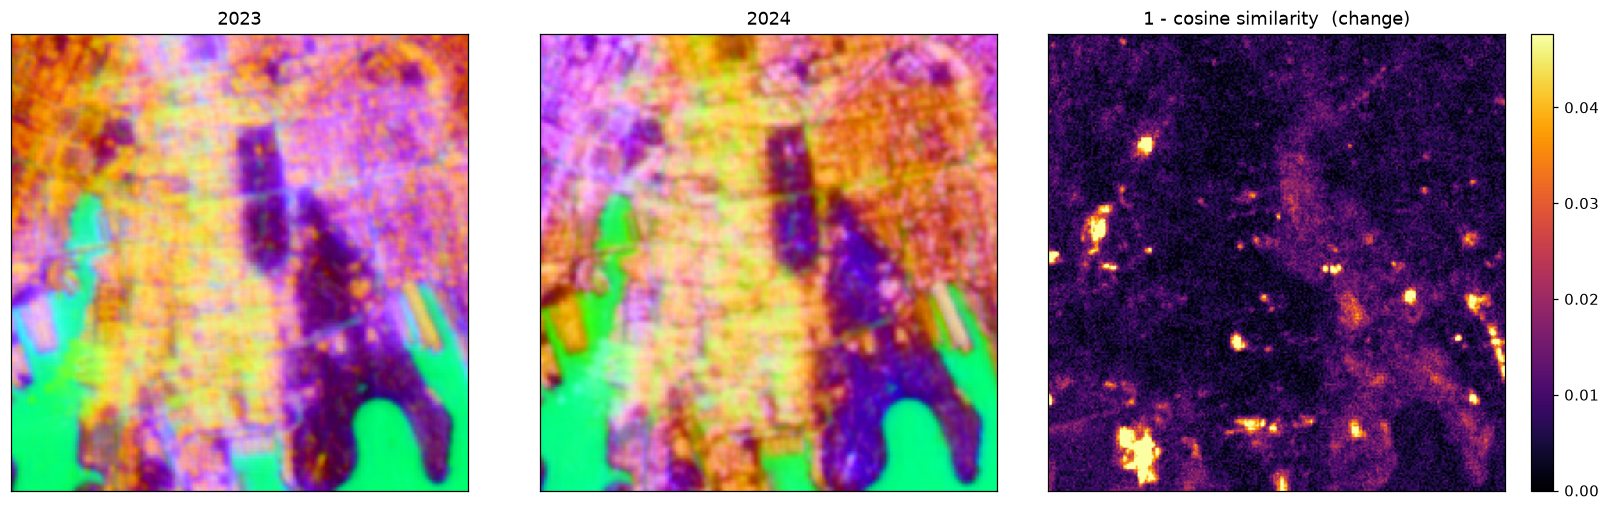

change: median 0.007, 95th percentile 0.020, max 0.210

No index was chosen. No band was chosen. No threshold was chosen.
And the map cannot tell you what kind of change it found.


In [18]:
if SOURCE == "live":
    try:
        idx_prev = E.aef_load_index(year=YEAR - 1, cache_path="aef_index_prev.parquet")
        h2 = E.aef_find_tiles(idx_prev, AOI_LON, AOI_LAT, year=YEAR - 1)
        EMB2, _, _ = E.aef_read_window(E.aef_tile_url(h2.iloc[0]["path"]),
                                       AOI_LON, AOI_LAT, size_px=WINDOW_PX, dequantise=False)
        X2 = E.aef_dequantise(EMB2)[:, :H, :Wd]
        year_a, year_b = YEAR - 1, YEAR
    except Exception as exc:
        print(f"Could not fetch {YEAR-1}: {type(exc).__name__}. Using the synthetic pair.")
        X2 = None
else:
    X2 = None

if X2 is None:
    after = E.demo_scene(size=WINDOW_PX, as_dn=True, cloud=True, burnt=True,
                         noise_sd=0.05, smooth_px=6)
    X2 = E.aef_dequantise(E.demo_embedding(after["SCL"], noise=0.06, smooth_px=6,
                                           noise_seed=99))[:, :H, :Wd]
    year_a, year_b = "before", "after"

both = np.all(np.isfinite(X), axis=0) & np.all(np.isfinite(X2), axis=0)
cos = np.where(both, np.sum(np.nan_to_num(X) * np.nan_to_num(X2), axis=0), np.nan)
change = 1.0 - cos
print(f"pixels valid in both years: {float(np.mean(both))*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
axes[0].imshow(rgb); axes[0].set_title(f"{year_a}")
rgb2, _, _ = pca_rgb(X2.reshape(B, -1).T, finite, (H, Wd))
axes[1].imshow(rgb2); axes[1].set_title(f"{year_b}")
im = axes[2].imshow(change, cmap="inferno", vmin=0, vmax=np.nanpercentile(change, 99))
axes[2].set_title("1 - cosine similarity  (change)")
fig.colorbar(im, ax=axes[2], fraction=0.046)
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print(f"change: median {np.nanmedian(change):.3f}, 95th percentile "
      f"{np.nanpercentile(change, 95):.3f}, max {np.nanmax(change):.3f}")
print()
print("No index was chosen. No band was chosen. No threshold was chosen.")
print("And the map cannot tell you what kind of change it found.")

---
# Part 8 — What people are doing with this, and what to be careful about

### Published applications

All of these are real and were checked at build time. The evaluation figures are the authors'
own, so treat them as claims by interested parties rather than independent audit.

| Application | Result reported |
|---|---|
| **The model itself** (Brown et al., arXiv:2507.22291) | Consistently outperformed every featurisation tested, without retraining; roughly 24% error reduction where labels are scarce |
| **Atoll ecosystem mapping**, Maldives (*Remote Sensing*, Sept 2026) | Croplands mapped at 86% user's accuracy from embeddings against 36% from single-date Sentinel-2 |
| **Land surface temperature downscaling** (*Comm. Earth & Environ.* 7:103, 2026) | 30 m Landsat LST downscaled to 10 m across 26 US cities; RMSE 1.57 °C, R² 0.73 |
| **Commercial platforms** | CARTO exposes the embeddings for similarity search and year-on-year change; Google now sells *Custom Satellite Embeddings* at intervals down to 5 days |

For sustainable finance specifically, the interesting property is not accuracy. It is that a
**consistent, global, annual representation** makes it possible to compare a project in Queensland
with one in Kalimantan on the same footing — which is precisely what carbon credit ratings have
struggled to do.

### Are the dimensions really meaningless?

Google's own documentation says the 64 bands should be interpreted **collectively**, and that
individual bands carry no independent meaning. That is the line used in the lecture, and it is
the safe default.

Recent work complicates it. A 2026 study using 12.1 million samples across the continental United
States reports that **individual embedding dimensions do map onto specific land surface
properties**, and that the full space reconstructs 12 of 26 environmental variables at R² above
0.90, with temperature and elevation approaching 0.97.

Both things can be true: no dimension was *designed* to mean anything, and yet the space is
structured enough that meaning can be recovered after the fact. **This is a live research
question, not a settled point**, and it matters commercially — if dimensions can be interpreted,
the auditability objection below gets weaker.

### The limits that will come up in an assurance conversation

**Provenance.** You cannot inspect why two parcels are similar. The answer is a weight matrix.

**Continuity.** This is a Google product. The README promises at least a year's notice of change,
which is a commitment, not a guarantee. NDVI, published in 1974, will still work in 2050.

**Version risk.** If the model is retrained, every downstream number moves, and your time series
develops a discontinuity that has nothing to do with the ground.

**Circularity of evaluation.** The most convenient labels for testing embeddings are often
themselves model outputs, as they were in Part 6 here. Measuring agreement with another model is
not measuring agreement with the world.

## Core exercises

**C1 — Build the bridge yourself.** In one paragraph, without using the word "vector", explain to
a colleague who took the NLP part of this subject what a satellite embedding is. Then state the
single most important way the analogy to word embeddings breaks down.

**C2 — Query something meaningful.** Use the interactive similarity search to pick a query pixel
in a specific land-cover type, choose a threshold, and report the area in hectares that matches.
Then change the threshold by 0.05 and report the area again. Which of the two numbers would you
put in a client report, and what would you say next to it?

**C3 — Break the de-quantisation.** Recompute the Part 4 similarity map using **raw int8** values
instead of de-quantised ones. The picture will still look like something. Explain precisely which
step of the calculation is invalid, and why a plausible-looking output is more dangerous than an
obviously broken one.

## Stretch exercises

**S1 — How low can the dimension go?** Redo Part 6 using only the first 4, 8, 16 and 32 principal
components instead of all 64. If 16 dimensions do nearly as well, what does that say about the
claim that all 64 are needed?

**S2 — Similarity is not identity.** Find two pixels with cosine similarity above 0.95 that are
far apart in the scene. Look at them in the 08a Sentinel-2 imagery. Are they really the same kind
of place, or has the embedding collapsed a distinction you care about?

**S3 — Price the continuity risk.** Write half a page for a model risk committee on what happens
to a production carbon model if the embedding provider releases a new model version mid-contract.
What would you monitor to detect it, and what would you contractually require?

**S4 — Test the interpretability claim.** Correlate each of the 64 dimensions against NDVI, MNDWI
and NBR computed from Sentinel-2 over the same area, using 08a. Do any dimensions line up
strongly with a hand-crafted index? Report the strongest three correlations, and be honest if the
answer is that none of them do.

---

## Where this goes next

You now know what an embedding is, how to search one, and what it costs you in auditability.

**Lecture 08d** asks the question this notebook deliberately did not: on a real task, with real
labels and honest cross-validation, do learned features actually beat the hand-crafted indices
you built in 08a? The answer matters, because everything above is only interesting if the
representation earns its keep.